In [10]:
import glob
from image import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

In [34]:
files = glob.glob("../../duke/public/rsna_challenge/train_images_nii/sub-*/*ax*T2*.nii.gz")

In [44]:
res = []
weird_files = []
for f in tqdm(files):
    img = Image(f)
    img.change_orientation("RSP")
    if img.dim[-2]>1.5 or img.dim[-3]<2 or img.dim[-3]>6.2:
        weird_files.append(f)
 
    else:
        res.append(img.dim)

  0%|          | 23/8178 [00:00<05:56, 22.89it/s]Image header specifies datatype 'int16', but array is of type 'float64'. Header metadata will be overwritten to use 'float64'.
Image header specifies datatype 'int16', but array is of type 'float64'. Header metadata will be overwritten to use 'float64'.
  6%|▌         | 460/8178 [00:24<10:18, 12.49it/s]Image header specifies datatype 'int16', but array is of type 'float64'. Header metadata will be overwritten to use 'float64'.
Image header specifies datatype 'int16', but array is of type 'float64'. Header metadata will be overwritten to use 'float64'.
 14%|█▎        | 1106/8178 [00:56<06:09, 19.12it/s]Image header specifies datatype 'int16', but array is of type 'float64'. Header metadata will be overwritten to use 'float64'.
Image header specifies datatype 'int16', but array is of type 'float64'. Header metadata will be overwritten to use 'float64'.
Image header specifies datatype 'int16', but array is of type 'float64'. Header metadata

In [65]:
weird_files = list(set(weird_files))
weird_subjects = [] 
for f in weird_files:
    subj = f.split("/")[-1].split("_")[0]
    weird_subjects.append(subj)
weird_subjects = list(set(weird_subjects))
weird_subjects

['sub-1084486898',
 'sub-777619397',
 'sub-823937142',
 'sub-3867046855',
 'sub-1180134227',
 'sub-1671676307',
 'sub-2508151528',
 'sub-3369277408',
 'sub-3495818564',
 'sub-3324678907',
 'sub-1908143210',
 'sub-414452265',
 'sub-326589617',
 'sub-391103067',
 'sub-2799503775',
 'sub-2509953825',
 'sub-4255570773',
 'sub-2278286820',
 'sub-208289456',
 'sub-372642770',
 'sub-44060036',
 'sub-1880970480',
 'sub-3919334786',
 'sub-1972541574',
 'sub-289846404',
 'sub-1723430291',
 'sub-2206871806',
 'sub-3650821463',
 'sub-861719444',
 'sub-183230492']

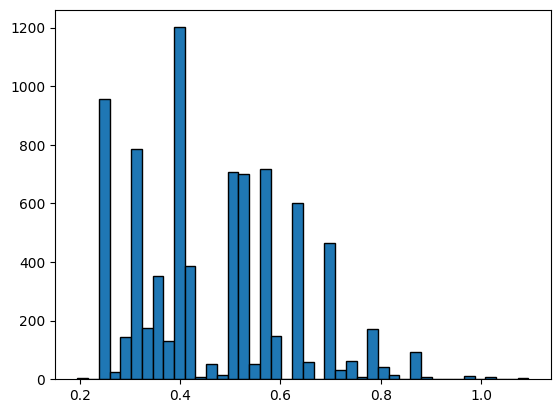

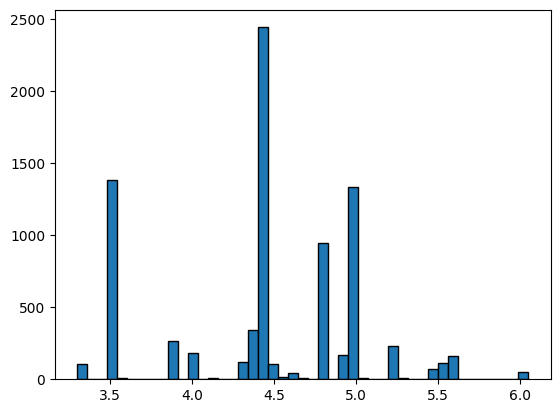

IndexError: index 2 is out of bounds for axis 1 with size 2

In [66]:
res = np.array(res)
res = res[:,-4:-1]
np.sum(res[:,0]==res[:,-1])/len(res)

plt.hist(res[:,0], bins="auto", edgecolor="k")
plt.title("Resolution along Right/Left axis")
plt.show()

plt.hist(res[:,1], bins="auto", edgecolor="k")
plt.title("Resolution along Superior/Inferior axis")
plt.show()

plt.hist(res[:,2], bins="auto", edgecolor="k")
plt.title("Resolution along Antero-posterior axis")
plt.show()